In [1]:
import numpy as np

np.random.seed(123)
n = 1000

clusters = np.random.choice([0, 1, 2], size=n, p=[0.3, 0.4, 0.3])

In [2]:
# continuous features (mixed distributions)
f1 = np.random.normal(loc=clusters*2, scale=1.0)
f2 = np.random.exponential(scale=1.5, size=n) + clusters
f3 = np.random.normal(0, 1, n) + clusters*0.5
f4 = np.random.lognormal(mean=0.3*clusters, sigma=0.6)

In [3]:
# engineered features
e1 = f1 * f2                    # interaction
e2 = f3 ** 2                    # polynomial
e3 = f4 / (f2 + 1e-3)           # ratio
e4 = f1 + f3                    # linear combo
e5 = np.random.normal(0, 1, n)   # noise

In [4]:
import pandas as pd

# categorical features from probabilistic mapping
p = 1/(1+np.exp(-f1))
cat = pd.cut(p, bins=[0, 0.33, 0.66, 1], labels=["A", "B", "C"])

In [5]:
# logistic target
logit = 1.2*f1 - 0.8*f2 + 0.6*f3 + 0.4*e1 + np.random.normal(0,1,n)
prob = 1/(1+np.exp(-logit))
y = (prob > 0.5).astype(int)

In [6]:
df = pd.DataFrame({
    'f1': f1, 'f2': f2, 'f3': f3, 'f4': f4,
    'e1': e1, 'e2': e2, 'e3': e3, 'e4': e4, 'e5': e5,
    'category': cat,
    'cluster_true': clusters,
    'target': y
})

print(df.head().to_string())

         f1        f2        f3        f4        e1        e2        e3        e4        e5 category  cluster_true  target
0  1.989967  2.037414 -1.103279  0.744242  4.054388  1.217224  0.365109  0.886689 -1.106314        C             1       1
1 -0.845644  2.595186 -0.920631  0.577658 -2.194604  0.847562  0.222502 -1.766276  0.933945        A             0       0
2  0.911461  0.639659 -0.243855  0.932655  0.583024  0.059465  1.455775  0.667606 -0.121420        C             0       0
3  0.625503  1.077690  1.102538  1.501078  0.674098  1.215589  1.391575  1.728041  1.011164        B             1       1
4  3.452934  2.632577  0.702669  2.572598  9.090117  0.493743  0.976846  4.155603  2.165832        C             2       1


In [7]:
df

,f1,f2,f3,f4,e1,e2,e3,e4,e5,category,cluster_true,target
0,1.989967,2.037414,-1.103279,0.744242,4.054388,1.217224,0.365109,0.886689,-1.106314,C,1,1
1,-0.845644,2.595186,-0.920631,0.577658,-2.194604,0.847562,0.222502,-1.766276,0.933945,A,0,0
2,0.911461,0.639659,-0.243855,0.932655,0.583024,0.059465,1.455775,0.667606,-0.121420,C,0,0
3,0.625503,1.077690,1.102538,1.501078,0.674098,1.215589,1.391575,1.728041,1.011164,B,1,1
4,3.452934,2.632577,0.702669,2.572598,9.090117,0.493743,0.976846,4.155603,2.165832,C,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.085897,2.695551,-0.050867,2.132308,0.231540,0.002587,0.790754,0.035030,1.489332,B,0,0
996,2.594040,8.090352,1.400036,0.627169,20.986698,1.960101,0.077511,3.994076,-0.417039,C,1,1
997,1.225667,2.115456,-0.367728,1.059712,2.592845,0.135224,0.500701,0.857939,-1.905801,C,1,1
998,-0.380291,1.360506,-0.576960,1.083699,-0.517388,0.332882,0.795956,-0.957251,1.946528,B,0,0


In [8]:
print(df.info())

print("\nShape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nCategory distribution:")
print(df["category"].value_counts())

print("\nTarget distribution:")
print(df["target"].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   f1            1000 non-null   float64 
 1   f2            1000 non-null   float64 
 2   f3            1000 non-null   float64 
 3   f4            1000 non-null   float64 
 4   e1            1000 non-null   float64 
 5   e2            1000 non-null   float64 
 6   e3            1000 non-null   float64 
 7   e4            1000 non-null   float64 
 8   e5            1000 non-null   float64 
 9   category      1000 non-null   category
 10  cluster_true  1000 non-null   int64   
 11  target        1000 non-null   int64   
dtypes: category(1), float64(9), int64(2)
memory usage: 87.1 KB
None

Shape: (1000, 12)

Missing values:
f1              0
f2              0
f3              0
f4              0
e1              0
e2              0
e3              0
e4              0
e5              0
category        0
clus

- *histogram*

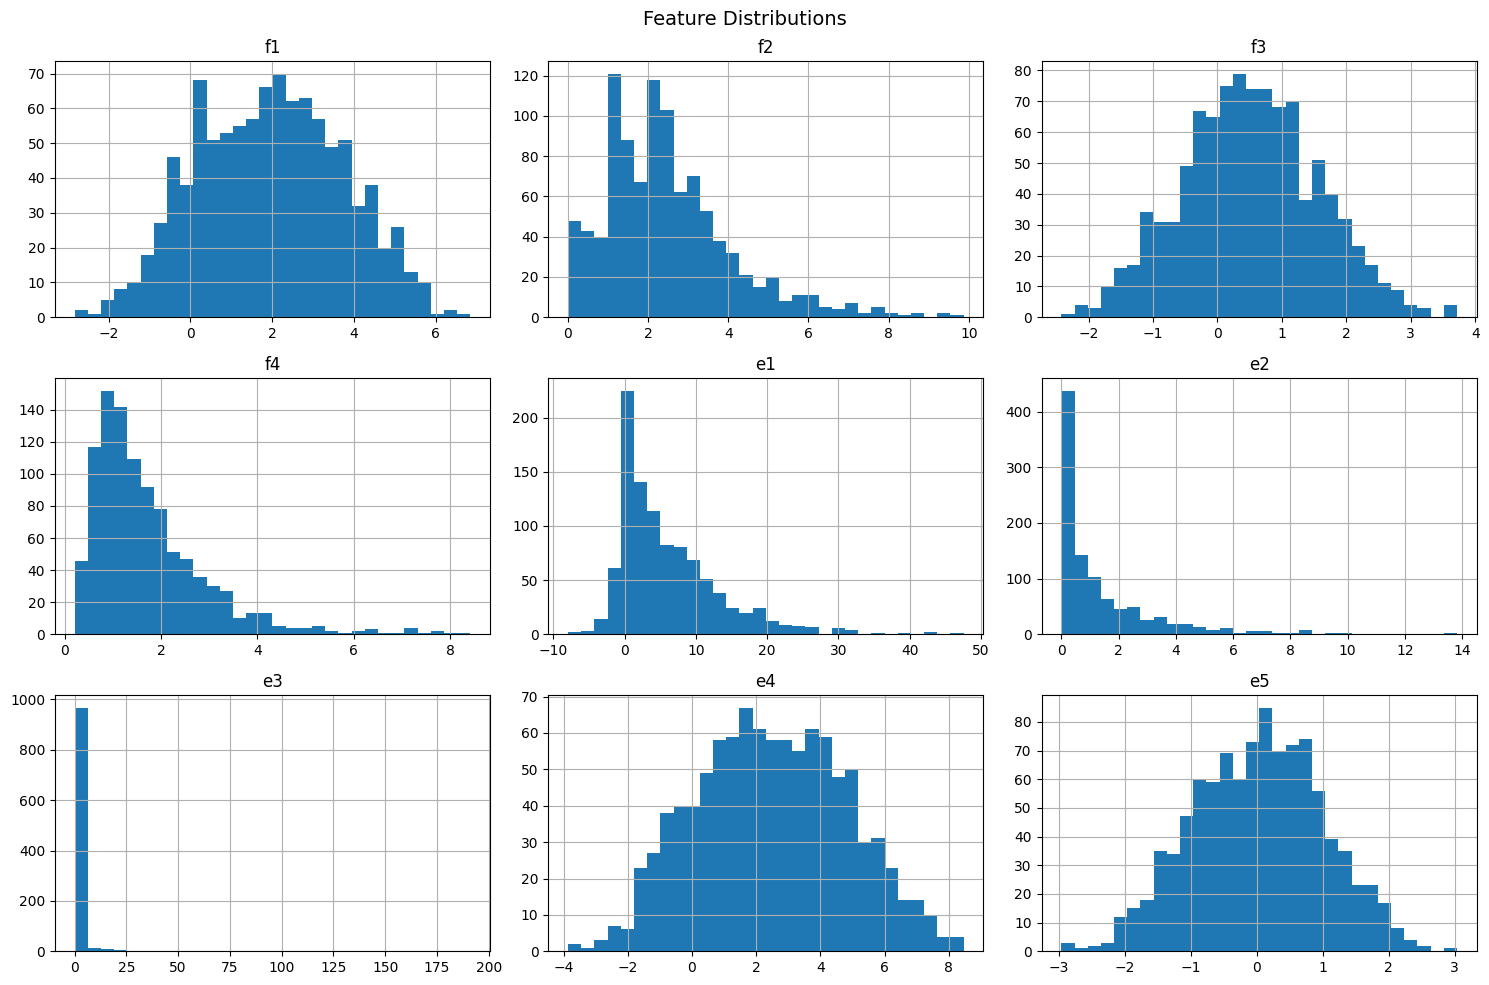

In [9]:
import matplotlib.pyplot as plt

cont_cols = ['f1', 'f2', 'f3', 'f4', 'e1', 'e2', 'e3', 'e4', 'e5']

df[cont_cols].hist(bins=30, figsize=(15,10))
plt.suptitle("Feature Distributions", fontsize=14)
plt.tight_layout()
plt.show()

> Several features (f2, f4, e1, e2, e3) are strongly right-skewed, while f1, f3, e4, and e5 look closer to Gaussian.

e3 clearly shows the most extreme skew with large outliers.

- For highly skewed positive variables, the common fix is a log transformation:

-> log(x)

-> or log1p(x) (safer when values may be near zero)

- *boxplot*

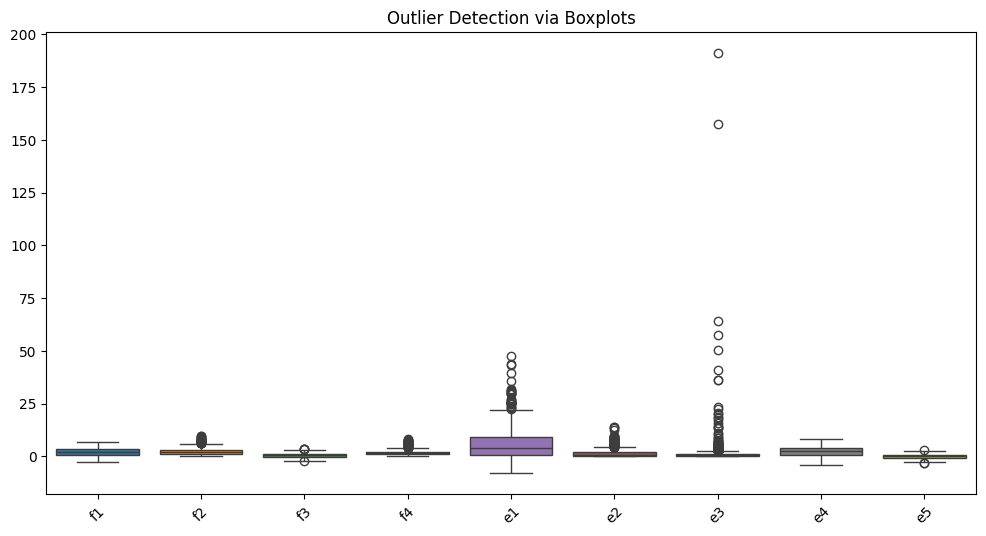

In [10]:
import seaborn as sns

plt.figure(figsize=(12,6))
sns.boxplot(data=df[cont_cols])
plt.title("Outlier Detection via Boxplots")
plt.xticks(rotation=45)
plt.show()

- *KDE*

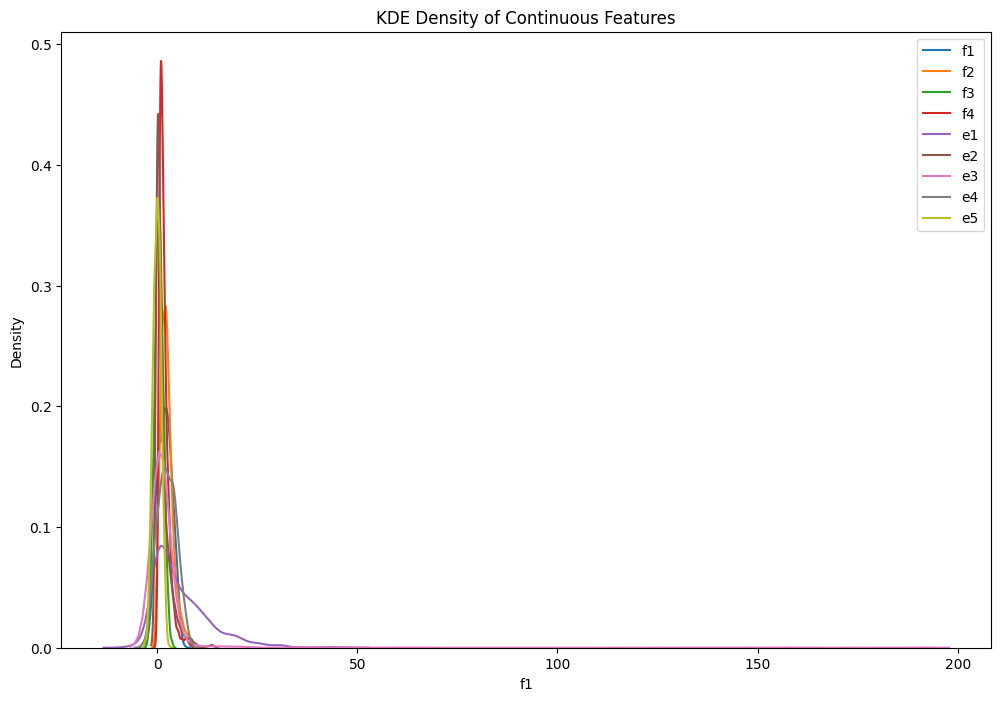

In [11]:
plt.figure(figsize=(12,8))

for col in cont_cols:
    sns.kdeplot(df[col], label=col)

plt.title("KDE Density of Continuous Features")
plt.legend()
plt.show()

- *categorical feature balance*

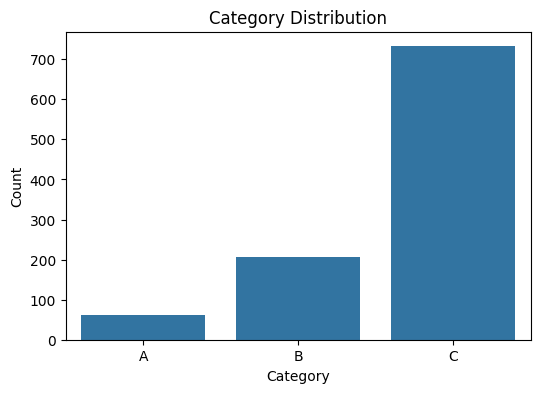

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(x="category", data=df)

plt.title("Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

> C dominating the dataset.
- can cause models to be biased towards th majority level
- struggle to learn patterns for rare level leading to overfitting

- *Heatmap to detect collinearity*

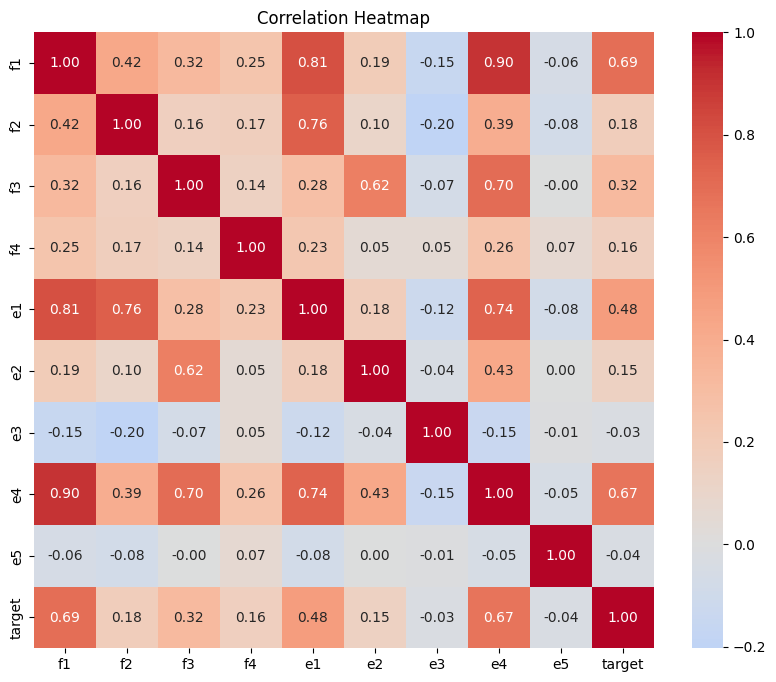

In [13]:
plt.figure(figsize=(10,8))

corr = df[cont_cols + ["target"]].corr()

sns.heatmap(corr, annot = True, cmap = "coolwarm", fmt=".2f", center=0)
plt.title("Correlation Heatmap")
plt.show()

Strong correlations appear between engineered features and their parent features (f1–e4, f1–e1, f2–e1, f3–e4), indicating potential multicollinearity.

- *Scatterplot*

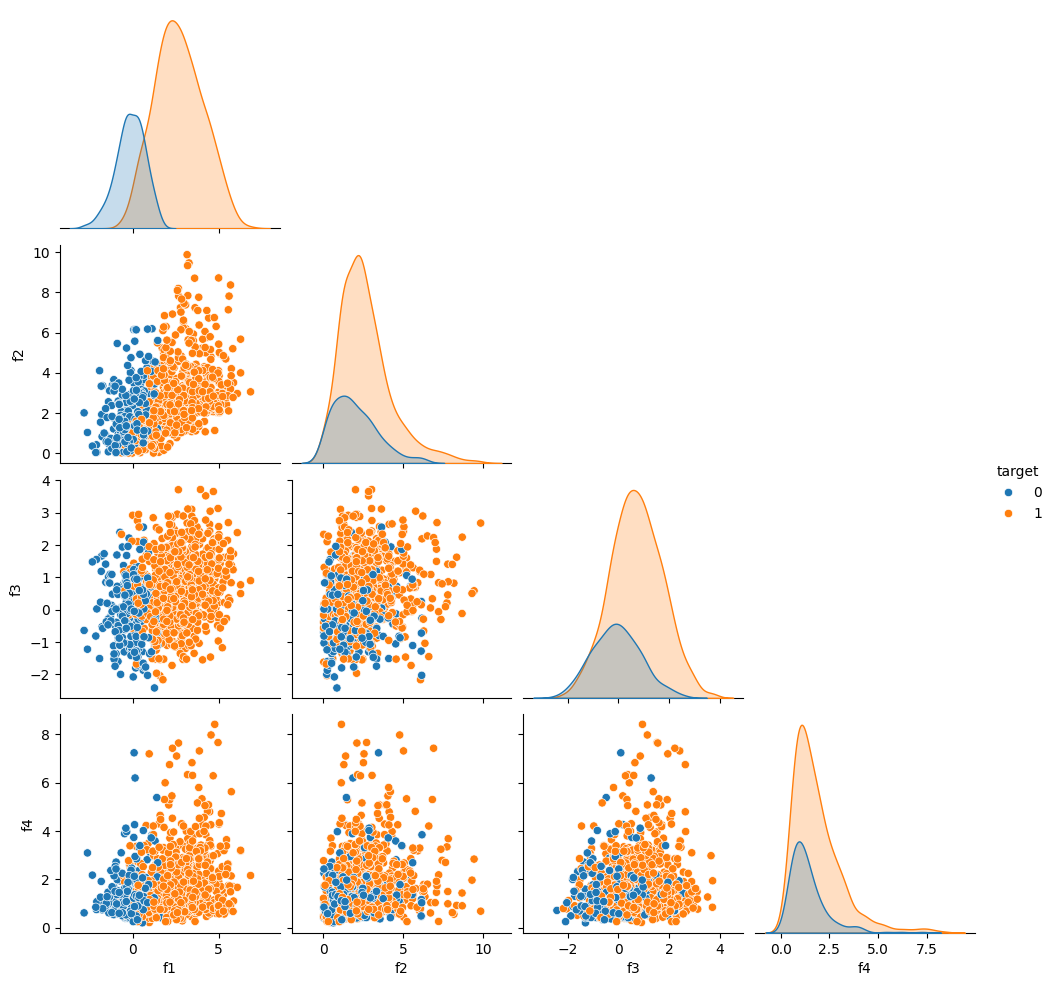

In [14]:
sns.pairplot(
    df[["f1", "f2", "f3", "f4", "target"]],
    hue = "target", corner = True
)

plt.show()

the plot correctly shows partial separation of target classes driven mainly by f1 and f4.

- *Category vs Target Relationship*

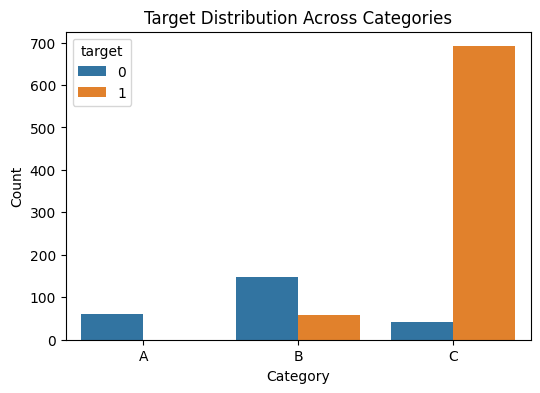

In [15]:
plt.figure(figsize = (6, 4))

sns.countplot(data=df, x="category", hue="target")

plt.title("Target Distribution Across Categories")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

- *A Random Forest quickly reveals which features carry the strongest predictive signal without requiring scaling*

In [16]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["target", "cluster_true"])
X = pd.get_dummies(X, columns=["category"], drop_first=True)

y = df["target"]

# first split: train (60) vs temp (40)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=123
)

# second split: validation (20) and test (20)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=123
)

print("Train size:", X_train.shape)
print("Validation size:", X_val.shape)
print("Test size:", X_test.shape)

Train size: (600, 11)
Validation size: (200, 11)
Test size: (200, 11)


In [17]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=123)

rf.fit(X_train, y_train)

val_acc = rf.score(X_val, y_val)

print("Validation Accuracy: ", val_acc)

Validation Accuracy:  0.935


the dataset has clear predictive signal

- *Feature Importance*

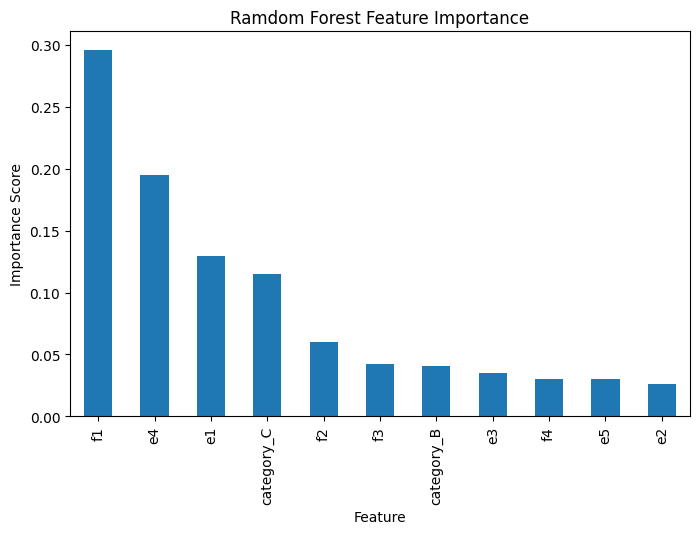

In [18]:
importance = pd.Series(rf.feature_importances_, index=X_train.columns)
importance = importance.sort_values(ascending=False)

plt.figure(figsize=(8,5))
importance.plot(kind = "bar")

plt.title("Ramdom Forest Feature Importance")
plt.ylabel("Importance Score")
plt.xlabel("Feature")
plt.show()

> Why might interaction features be especially useful for linear models like Logistic Regression?

- Because linear models cannot automatically capture relationships between features, so interaction terms must be manually added to model combined effects.

- *Tree vs Linear Model*

In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ("Scalar", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000))
    ])

pipe.fit(X_train, y_train)

val_acc_lr = pipe.score(X_val, y_val)

print("Logistic Regression Vaidation Accuracy : ", val_acc_lr)

Logistic Regression Vaidation Accuracy :  0.935


dataset is largely linearly separable after feature engineering

- *PCA*

In [20]:
from sklearn.decomposition import PCA

scalar = StandardScaler()
X_scaled = scalar.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio: ", pca.explained_variance_ratio_)

Explained variance ratio:  [0.40520093 0.1372705 ]


54% information retained

- *PCA Visualization with True Clusters*

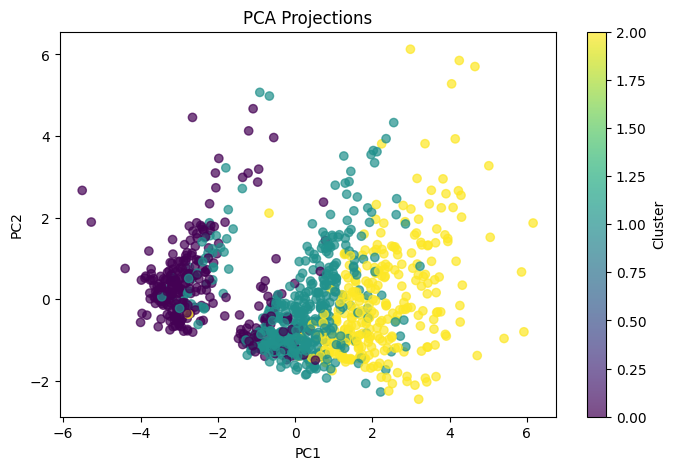

In [21]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c = df["cluster_true"],
    cmap = "viridis",
    alpha = 0.7
)

plt.title("PCA Projections")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.colorbar(label="Cluster")
plt.show()

- *We apply KMeans to see whether an unsupervised algorithm can recover the cluster structure present in the dataset.*

In [25]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=123)

kmeans_labels = kmeans.fit_predict(X_scaled)

df["kmeans_cluster"] = kmeans_labels

print(df[["cluster_true", "kmeans_cluster"]].head())

   cluster_true  kmeans_cluster
0             1               2
1             0               1
2             0               2
3             1               1
4             2               2


In [27]:
print(pd.crosstab(df["cluster_true"], df["kmeans_cluster"]))

kmeans_cluster    0    1    2
cluster_true                 
0                 0  222   65
1                56   44  327
2               207    2   77


- *Compute Clustering Quality*

In [28]:
from sklearn.metrics import adjusted_rand_score

ari = adjusted_rand_score(df["cluster_true"], df["kmeans_cluster"])

print("Adjusted Rand Index:", ari)

Adjusted Rand Index: 0.3890926797621933


- *PCA Visualization of KMeans Clusters*

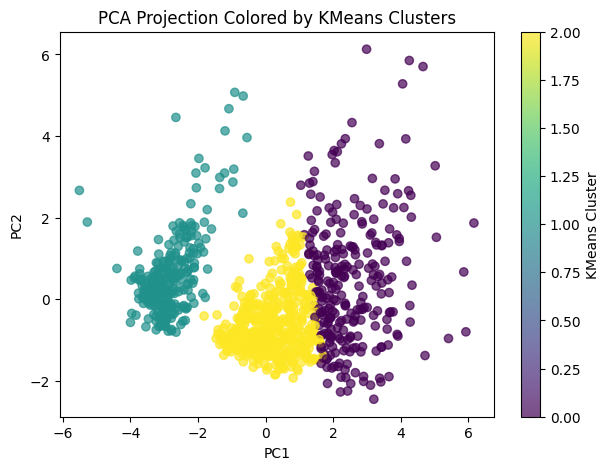

In [29]:
plt.figure(figsize=(7,5))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df["kmeans_cluster"],
    cmap="viridis",
    alpha=0.7
)

plt.title("PCA Projection Colored by KMeans Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.colorbar(label="KMeans Cluster")
plt.show()